Using device: cuda
Start Training...
Epoch 5, Avg Loss: 0.0338
Epoch 10, Avg Loss: 0.0126
Epoch 15, Avg Loss: 0.0113
Epoch 20, Avg Loss: 0.0109


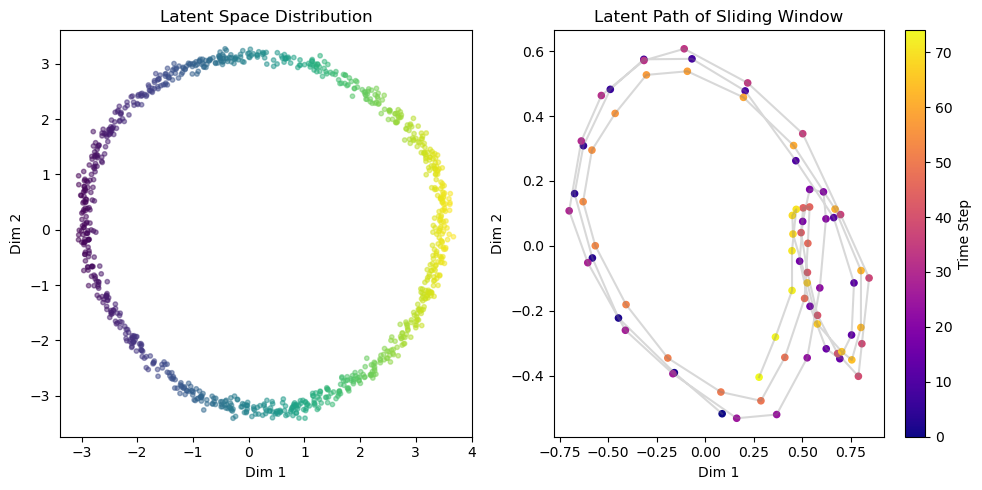

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Sample Data Generation
# -----------------------------
def generate_time_series(n_samples=1000, seq_len=50):
    X = []
    for _ in range(n_samples):
        phase = np.random.rand() * 2 * np.pi
        t = np.linspace(0, 4*np.pi, seq_len)
        # 加入一些隨機性與正弦波
        series = np.sin(t + phase) + 0.1*np.random.randn(seq_len)
        X.append(series)
    return np.array(X, dtype=np.float32)

X = generate_time_series()
X = X[..., np.newaxis]  # shape: (n_samples, seq_len, 1)
dataset = torch.tensor(X)

# -----------------------------
# 2. Device Setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 3. AutoEncoder Class (修正處)
# -----------------------------
class TimeSeriesAutoEncoder(nn.Module):
    def __init__(self, seq_len=50, latent_dim=2):
        super(TimeSeriesAutoEncoder, self).__init__()
        
        # Encoder
        # 50 -> 25 -> 12
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear((seq_len//4)*8, latent_dim)
        )
        
        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, (seq_len//4)*8)
        
        self.decoder_layer1 = nn.Sequential(
            # 修正點：加入 output_padding=1
            # Input: 12 -> Output: (12-1)*2 - 2*1 + 4 + 1 = 25
            nn.ConvTranspose1d(8, 16, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU()
        )
        
        self.decoder_layer2 = nn.Sequential(
            # Input: 25 -> Output: (25-1)*2 - 2*1 + 4 + 0 = 50
            nn.ConvTranspose1d(16, 1, kernel_size=4, stride=2, padding=1),
            # 這裡是最後輸出，通常不需要 ReLU，除非你確定數據大於0。
            # 這裡保持原始設計，但建議如果數據有負值，最後一層不要加激活函數，或者用 Tanh
        )

    def forward(self, x):
        # x shape: (batch, seq_len, 1) -> (batch, 1, seq_len)
        x = x.permute(0, 2, 1)
        latent = self.encoder(x)
        
        x = self.decoder_fc(latent)
        x = x.view(x.size(0), 8, -1)  # Reshape to (Batch, 8, 12)
        
        x = self.decoder_layer1(x)    # Output (Batch, 16, 25)
        out = self.decoder_layer2(x)  # Output (Batch, 1, 50)
        
        out = out.permute(0, 2, 1)    # back to (batch, seq_len, 1)
        return out, latent

# -----------------------------
# 4. Training
# -----------------------------
model = TimeSeriesAutoEncoder(seq_len=50, latent_dim=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 20 # 稍微增加 epoch 看效果
batch_size = 32

print("Start Training...")
for epoch in range(n_epochs):
    perm = torch.randperm(len(dataset))
    total_loss = 0
    for i in range(0, len(dataset), batch_size):
        batch_idx = perm[i:i+batch_size]
        batch = dataset[batch_idx].to(device)
        
        optimizer.zero_grad()
        recon, _ = model(batch)
        
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Avg Loss: {total_loss / (len(dataset)/batch_size):.4f}")

# -----------------------------
# 5. Latent Feature Extraction & Visualization
# -----------------------------
# Visualization Trick 1: Scatter plot
model.eval()
with torch.no_grad():
    _, latent_features = model(dataset.to(device))
    latent_features = latent_features.cpu().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(latent_features[:,0], latent_features[:,1], alpha=0.5, s=10, c=latent_features[:,0], cmap='viridis')
plt.title("Latent Space Distribution")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Visualization Trick 2: Path of a sliding window
# 熊熊注意：原本你的代碼中 single_seq 長度只有 50，滑動視窗也是 50，這樣迴圈 range(0, 0) 不會執行。
# 這裡我生成一個長序列來做示範，讓你看到連續的軌跡。
long_seq_len = 200
t_long = np.linspace(0, 8*np.pi, long_seq_len)
long_series = np.sin(t_long) + 0.05*np.random.randn(long_seq_len)
long_series = torch.tensor(long_series, dtype=torch.float32).view(1, -1, 1).to(device) # (1, 200, 1)

windows = []
# 滑動窗口：從長序列中切出重疊的 50 長度片段
for i in range(0, long_seq_len - 50, 2): 
    w = long_series[:, i:i+50, :]
    windows.append(w)

latent_path = []
with torch.no_grad():
    for w in windows:
        _, z = model(w)
        latent_path.append(z.cpu().numpy()[0])
latent_path = np.array(latent_path)

plt.subplot(1, 2, 2)
# 畫出軌跡，並用顏色表示時間推進
plt.plot(latent_path[:,0], latent_path[:,1], '-', alpha=0.3, color='gray') 
plt.scatter(latent_path[:,0], latent_path[:,1], c=np.arange(len(latent_path)), cmap='plasma', s=20)
plt.title("Latent Path of Sliding Window")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Time Step")

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子確保結果可重現
torch.manual_seed(42)
np.random.seed(42)

class StateAwareNet(nn.Module):
    """
    神經網路本體：負責特徵提取、狀態分類與訊號重構
    """
    def __init__(self, num_features, hidden_dim, window_size):
        super(StateAwareNet, self).__init__()
        
        # 1. Encoder: 提取波形幾何特徵 (Slope, Variance)
        # 使用 Conv1d 捕捉時間窗口內的局部特徵
        self.encoder = nn.Sequential(
            nn.Conv1d(num_features, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # 2. State Head: 狀態機率輸出
        # 輸出通道數 = 特徵數 * 3 (狀態: 0=OFF, 1=SWITCH, 2=ON)
        self.state_head = nn.Conv1d(hidden_dim, num_features * 3, kernel_size=1)
        
        # 3. Decoder: 重構原始訊號
        self.decoder = nn.Conv1d(hidden_dim, num_features, kernel_size=1)

    def forward(self, x):
        # x shape: (Batch, Seq_Len, Features) -> Permute to (Batch, Features, Seq_Len)
        x_in = x.permute(0, 2, 1)
        
        # Latent Representation
        latent = self.encoder(x_in)
        
        # State Prediction
        state_logits = self.state_head(latent) # (Batch, Feat*3, Seq)
        
        # Reshape for easier handling: (Batch, Seq, Feat, 3_States)
        batch, _, seq_len = state_logits.shape
        num_features = x.shape[2]
        state_probs = state_logits.view(batch, num_features, 3, seq_len).permute(0, 3, 1, 2)
        state_probs = F.softmax(state_probs, dim=-1) # 轉為機率
        
        # Reconstruction
        recon = self.decoder(latent).permute(0, 2, 1)
        
        return recon, state_probs

class LogicStateAE:
    """
    Scikit-learn 風格的包裝器
    """
    def __init__(self, 
                 window_size=20, 
                 n_features=2, 
                 hidden_dim=32, 
                 lr=0.005, 
                 batch_size=32,
                 logic_weight=5.0,     # 互斥邏輯懲罰權重
                 transition_weight=2.0 # 狀態轉換懲罰權重
                 ):
        self.window_size = window_size
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.batch_size = batch_size
        self.logic_weight = logic_weight
        self.transition_weight = transition_weight
        
        self.model = StateAwareNet(n_features, hidden_dim, window_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.mse_loss = nn.MSELoss()
        
    def _compute_loss(self, recon, original, state_probs):
        """
        計算混合損失函數：MSE + 邏輯約束 + 狀態轉換約束
        """
        # 1. 基礎重建誤差 (MSE)
        loss_mse = self.mse_loss(recon, original)
        
        # 2. 互斥邏輯 (Mutual Exclusion)
        # 假設 Feature 0 和 Feature 1 互斥
        # 定義 "Active" 為 狀態 1 (SWITCH) 或 狀態 2 (ON)
        # 懲罰: P(A is Active) * P(B is Active)
        prob_active = state_probs[..., 1] + state_probs[..., 2] # Sum of state 1 & 2
        
        # 硬編碼互斥對 (0, 1) -> 可擴展為參數
        conflict = prob_active[..., 0] * prob_active[..., 1]
        loss_logic = torch.mean(conflict)
        
        # 3. 狀態轉換約束 (Transition Constraint)
        # 禁止瞬間跳變: OFF(t) -> ON(t+1) 是禁止的，必須經過 SWITCH
        # 懲罰: P(State=0 at t) * P(State=2 at t+1)
        prob_off_curr = state_probs[:, :-1, :, 0]
        prob_on_next = state_probs[:, 1:, :, 2]
        loss_trans = torch.mean(prob_off_curr * prob_on_next)
        
        total_loss = loss_mse + (self.logic_weight * loss_logic) + (self.transition_weight * loss_trans)
        return total_loss, loss_mse, loss_logic, loss_trans

    def fit(self, X, epochs=50, verbose=True):
        """
        訓練模型
        X shape: (Batch, Window_Size, Features) 
        或者是長序列，這裡假設已經切好 Window
        """
        dataset = TensorDataset(torch.FloatTensor(X))
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        history = []
        
        for epoch in range(epochs):
            total_mse = 0
            total_logic = 0
            
            for batch_x in loader:
                x = batch_x[0]
                self.optimizer.zero_grad()
                
                recon, state_probs = self.model(x)
                loss, mse, logic, _ = self._compute_loss(recon, x, state_probs)
                
                loss.backward()
                self.optimizer.step()
                
                total_mse += mse.item()
                total_logic += logic.item()
                
            avg_mse = total_mse / len(loader)
            avg_logic = total_logic / len(loader)
            history.append(avg_mse)
            
            if verbose and (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | MSE: {avg_mse:.4f} | Logic Vio: {avg_logic:.4f}")
        
        return history

    def predict(self, X):
        """
        推論與異常評分
        回傳: 重建訊號, 狀態機率, 異常分數 (MSE + Logic Penalty)
        """
        self.model.eval()
        with torch.no_grad():
            x_tensor = torch.FloatTensor(X)
            recon, state_probs = self.model(x_tensor)
            
            # 計算 Point-wise Anomaly Score
            # 1. 重建誤差 (幾何異常)
            mse_score = torch.mean((x_tensor - recon)**2, dim=2) # (Batch, Seq)
            
            # 2. 邏輯違規分數 (語義異常)
            prob_active = state_probs[..., 1] + state_probs[..., 2]
            logic_score = prob_active[..., 0] * prob_active[..., 1] # (Batch, Seq)
            
            # 綜合分數 (可調整權重)
            anomaly_score = mse_score + (self.logic_weight * logic_score)
            
        return recon.numpy(), state_probs.numpy(), anomaly_score.numpy()

In [8]:
class MechanismSimulator:
    def generate_normal_sequence(self, total_len=1000):
        t = np.linspace(0, total_len, total_len)
        sig_a = np.ones(total_len) * 10.0
        sig_b = np.ones(total_len) * 10.0
        
        # 定義一個完整的 cycle: A_ON -> B_ON -> A_ON...
        # 每個事件長度約 60: Switch(10) + On(40) + Reset(10)
        current_t = 20
        while current_t < total_len - 80:
            # 決定誰啟動 (輪流或隨機，這裡用輪流以確保互斥)
            active_sig = sig_a if (current_t // 100) % 2 == 0 else sig_b
            
            # Phase 1: Switch (Drop) - 10 steps
            active_sig[current_t : current_t+10] = np.linspace(10.0, 5.0, 10)
            
            # Phase 2: ON (Oscillate) - 40 steps
            w = np.linspace(0, 8*np.pi, 40)
            noise = np.random.normal(0, 0.2, 40)
            active_sig[current_t+10 : current_t+50] = 5.0 + 0.5*np.sin(w) + noise
            
            # Phase 3: Reset (Back to OFF) - 10 steps
            active_sig[current_t+50 : current_t+60] = np.linspace(5.0, 10.0, 10)
            
            current_t += 80 # 下一個事件
            
        return np.stack([sig_a, sig_b], axis=1)

    def generate_anomaly_both_on(self, seq_len=100):
        # 異常：兩個同時震盪 (ON)
        t = np.linspace(0, seq_len, seq_len)
        w = np.linspace(0, 4*np.pi, seq_len)
        noise = np.random.normal(0, 0.2, seq_len)
        
        # 兩者都在 5.0 附近震盪
        sig_a = 5.0 + 0.5*np.sin(w) + noise
        sig_b = 5.0 + 0.5*np.cos(w) + noise # 稍微不同相位
        
        return np.stack([sig_a, sig_b], axis=1)

    def generate_anomaly_deadlock(self, seq_len=100):
        # 異常：兩個都死掉 (都在 10.0 不動)
        # 視需求而定，這算不算異常取決於邏輯定義
        return np.ones((seq_len, 2)) * 10.0

# 輔助函式：切分 Sliding Windows
def create_windows(data, window_size, step=5):
    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i+window_size])
    return np.array(windows)

Training Data Shape: (297, 30, 2)
Epoch 10/60 | MSE: 0.4985 | Logic Vio: 0.0000
Epoch 20/60 | MSE: 0.0944 | Logic Vio: 0.0000
Epoch 30/60 | MSE: 0.0703 | Logic Vio: 0.0000
Epoch 40/60 | MSE: 0.0591 | Logic Vio: 0.0000
Epoch 50/60 | MSE: 0.0511 | Logic Vio: 0.0000
Epoch 60/60 | MSE: 0.0441 | Logic Vio: 0.0000


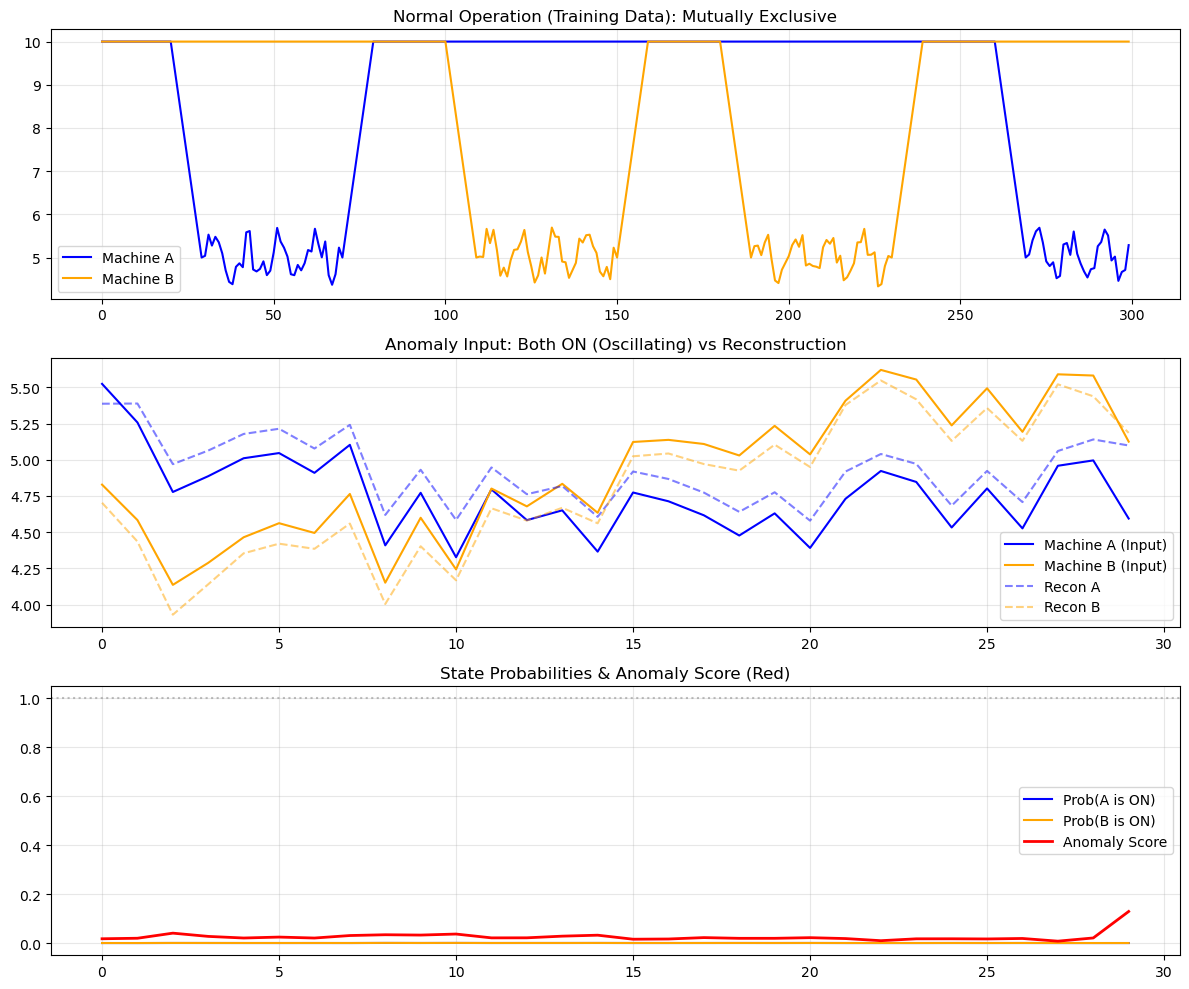

In [10]:
# ==========================================
# 1. 準備數據
# ==========================================
sim = MechanismSimulator()
# 生成 3000 點的正常交互資料
normal_data_raw = sim.generate_normal_sequence(total_len=3000)
# 切分成視窗 (Window Size = 30)
train_windows = create_windows(normal_data_raw, window_size=30, step=10)

print(f"Training Data Shape: {train_windows.shape}")

# ==========================================
# 2. 訓練模型
# ==========================================
# 熊熊注意：這裡我們強調 logic_weight，迫使模型學會"只能有一個在震盪"
model = LogicStateAE(window_size=30, n_features=2, hidden_dim=16, logic_weight=10.0)
history = model.fit(train_windows, epochs=60)

# ==========================================
# 3. 測試異常場景：雙開 (Mutual Exclusion Violation)
# ==========================================
# 生成異常數據 (100點長)
anomaly_raw = sim.generate_anomaly_both_on(seq_len=100)
# 將其包裝成 batch 進行預測 (只取一段視窗來觀察)
test_window = anomaly_raw[20:50].reshape(1, 30, 2) 

recon, states, scores = model.predict(test_window)

# ==========================================
# 4. 視覺化結果分析 (修正版)
# ==========================================
plt.figure(figsize=(12, 10))

# --- 圖 1: 正常訓練數據 (前 300 點) ---
plt.subplot(3, 1, 1)
plt.plot(normal_data_raw[:300, 0], label='Machine A', color='blue')
plt.plot(normal_data_raw[:300, 1], label='Machine B', color='orange')
plt.title("Normal Operation (Training Data): Mutually Exclusive")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 圖 2: 異常輸入波形 (雙開) ---
plt.subplot(3, 1, 2)
plt.plot(test_window[0, :, 0], label='Machine A (Input)', color='blue', linestyle='-')
plt.plot(test_window[0, :, 1], label='Machine B (Input)', color='orange', linestyle='-')
plt.plot(recon[0, :, 0], label='Recon A', color='blue', linestyle='--', alpha=0.5)
plt.plot(recon[0, :, 1], label='Recon B', color='orange', linestyle='--', alpha=0.5)
plt.title("Anomaly Input: Both ON (Oscillating) vs Reconstruction")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 圖 3: 狀態機率與異常分數 (修正這裡) ---
plt.subplot(3, 1, 3)

# states 的形狀是 (Batch, Seq_Len, Features, 3_States)
# 我們要取 Batch=0, 所有時間點, Feature=0 (Machine A), State=2 (ON)
p_on_a = states[0, :, 0, 2] 
p_on_b = states[0, :, 1, 2] 

x_axis = np.arange(30)

plt.plot(x_axis, p_on_a, label='Prob(A is ON)', color='blue')
plt.plot(x_axis, p_on_b, label='Prob(B is ON)', color='orange')
plt.plot(x_axis, scores[0], label='Anomaly Score', color='red', linewidth=2, linestyle='-')

plt.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
plt.title("State Probabilities & Anomaly Score (Red)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()